In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# импорт модулей, для проверки функций dataset.py
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# подгрузка пользовательских модулей
import dataset



In [ ]:
# Импорт данных
data = dataset.load_data('anxiety_depression_data.csv')
data.head()

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Chronic_Illnesses,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
0,56,Male,Bachelor's,Unemployed,6.0,0.4,3,4,2,9,...,0,NaN,0,1,NaN,4,3,7,5,1
1,69,Female,Bachelor's,Retired,8.8,2.8,6,18,7,6,...,0,NaN,1,0,NaN,1,4,7,4,6
2,46,Female,Master's,Employed,5.3,1.6,5,5,13,8,...,0,NaN,0,1,NaN,8,7,8,1,1
3,32,Female,High School,Unemployed,8.8,0.5,4,6,3,4,...,1,NaN,0,0,NaN,7,4,8,4,4
4,60,Female,Bachelor's,Retired,7.2,0.7,2,7,15,3,...,0,NaN,1,1,Frequent,8,9,5,7,7


In [ ]:
# информация о загруженном датасете - общая сводка
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1200 non-null   int64  
 1   Gender                         1200 non-null   object 
 2   Education_Level                1200 non-null   object 
 3   Employment_Status              1200 non-null   object 
 4   Sleep_Hours                    1200 non-null   float64
 5   Physical_Activity_Hrs          1200 non-null   float64
 6   Social_Support_Score           1200 non-null   int64  
 7   Anxiety_Score                  1200 non-null   int64  
 8   Depression_Score               1200 non-null   int64  
 9   Stress_Level                   1200 non-null   int64  
 10  Family_History_Mental_Illness  1200 non-null   int64  
 11  Chronic_Illnesses              1200 non-null   int64  
 12  Medication_Use                 453 non-null    o

In [ ]:
# информация о числовых полях
data.describe()

,Age,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,Family_History_Mental_Illness,Chronic_Illnesses,Therapy,Meditation,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
count,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000
mean,46.317500,6.46900,2.005750,5.055000,10.470000,10.674167,5.000833,0.318333,0.26750,0.210000,0.399167,4.992500,4.889167,5.062500,5.12000,4.959167
std,16.451157,1.52955,2.037818,2.652893,5.911138,5.632889,2.538281,0.466024,0.44284,0.407478,0.489931,2.590953,2.547016,2.531587,2.56991,2.566383
min,18.000000,2.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,33.000000,5.40000,0.600000,3.000000,5.000000,6.000000,3.000000,0.000000,0.00000,0.000000,0.000000,3.000000,3.000000,3.000000,3.00000,3.000000
50%,46.000000,6.40000,1.400000,5.000000,10.500000,11.000000,5.000000,0.000000,0.00000,0.000000,0.000000,5.000000,5.000000,5.000000,5.00000,5.000000
75%,61.000000,7.50000,2.700000,7.000000,16.000000,15.000000,7.000000,1.000000,1.00000,0.000000,1.000000,7.000000,7.000000,7.000000,7.00000,7.000000
max,74.000000,12.40000,15.100000,9.000000,20.000000,20.000000,9.000000,1.000000,1.00000,1.000000,1.000000,9.000000,9.000000,9.000000,9.00000,9.000000


In [ ]:
# информация о вещественных полях
data.describe(include='object')

,Gender,Education_Level,Employment_Status,Medication_Use,Substance_Use
count,1200,1200,1200,453,366
unique,4,5,4,2,2
top,Female,PhD,Employed,Regular,Occasional
freq,569,262,320,238,242


In [ ]:
dataset.data_miss(data)

"""
total_data = data.isna().sum().sort_values(ascending=False)
percentage_data = ((data.isna().sum()*100)/(data.shape[0])).sort_values(ascending=False)

table_data = pd.concat([total_data, percentage_data], axis=1, keys=['Total missing values', 'Total Percentage'])
print(table_data)
"""

                               Total missing values  Total Percentage
Substance_Use                                   834             69.50
Medication_Use                                  747             62.25
Education_Level                                   0              0.00
Gender                                            0              0.00
Age                                               0              0.00
Sleep_Hours                                       0              0.00
Employment_Status                                 0              0.00
Anxiety_Score                                     0              0.00
Physical_Activity_Hrs                             0              0.00
Depression_Score                                  0              0.00
Stress_Level                                      0              0.00
Family_History_Mental_Illness                     0              0.00
Social_Support_Score                              0              0.00
Chronic_Illnesses   

"\ntotal_data = data.isna().sum().sort_values(ascending=False)\npercentage_data = ((data.isna().sum()*100)/(data.shape[0])).sort_values(ascending=False)\n\ntable_data = pd.concat([total_data, percentage_data], axis=1, keys=['Total missing values', 'Total Percentage'])\nprint(table_data)\n"

In [ ]:
# Значения для параметра "Прием лекарств"
data['Medication_Use'].unique()

array([nan, 'Occasional', 'Regular'], dtype=object)

In [ ]:
# Значения для параметра "Прием психотропных веществ"
data['Substance_Use'].unique()

array([nan, 'Frequent', 'Occasional'], dtype=object)

In [ ]:
# замена отсутствующих значений
data['Medication_Use'] = data['Medication_Use'].fillna('None')
data['Substance_Use'] = data['Substance_Use'].fillna('None')

print(data['Medication_Use'].isna().sum())
print(data['Substance_Use'].isna().sum())

0
0


In [ ]:
data.describe(include='object')

,Gender,Education_Level,Employment_Status,Medication_Use,Substance_Use
count,1200,1200,1200,1200,1200
unique,4,5,4,3,3
top,Female,PhD,Employed,None,None
freq,569,262,320,747,834


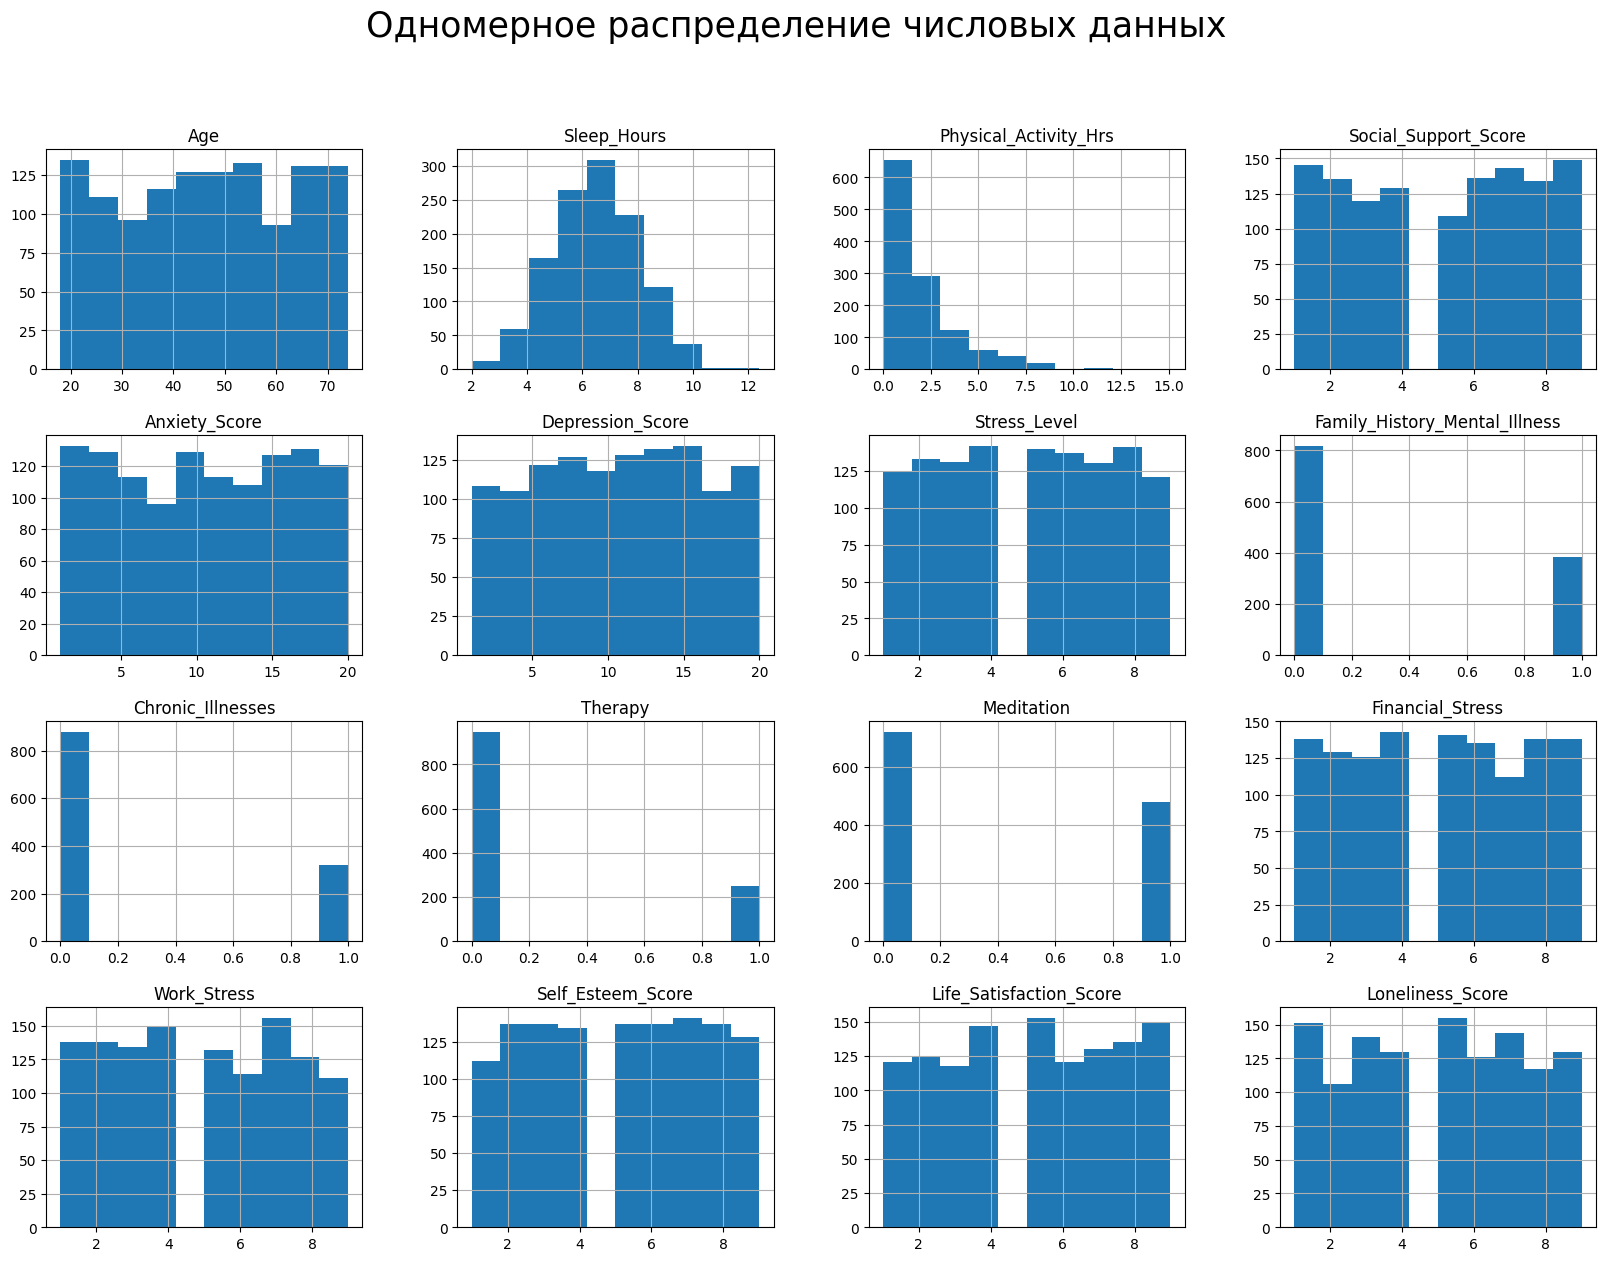

In [ ]:
# Разделение числовых и вещественных данных
data_num = data.select_dtypes(include=['int64', 'float64'])
data_cat = data.select_dtypes(include=['object'])

# Одномерное распределение числовых значений
data.hist(figsize=(20, 14), grid=True)
plt.suptitle('Одномерное распределение числовых данных', fontsize=25)
plt.show()

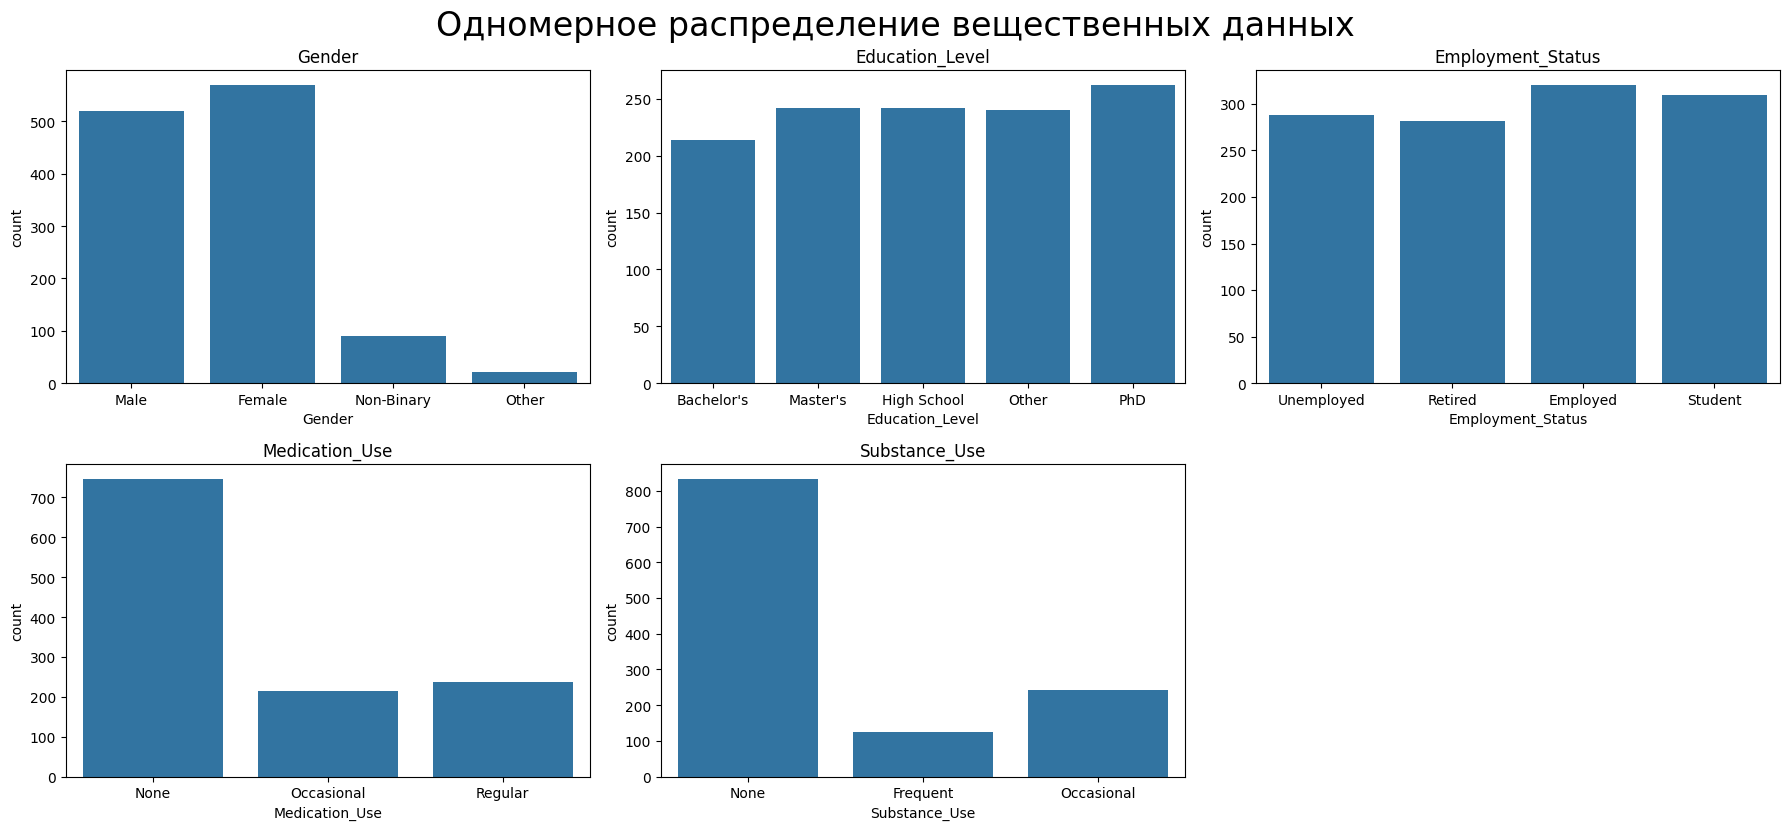

In [ ]:
# Одномерное распределение вещественных значений
i = 1
plt.figure(figsize=(18, 12))
for col in data_cat.columns:
    plt.subplot(3,3,i)
    sns.countplot(x=data_cat[col])
    plt.title(col)
    i += 1
plt.suptitle('Одномерное распределение вещественных данных', fontsize=24)
plt.tight_layout()
plt.show()

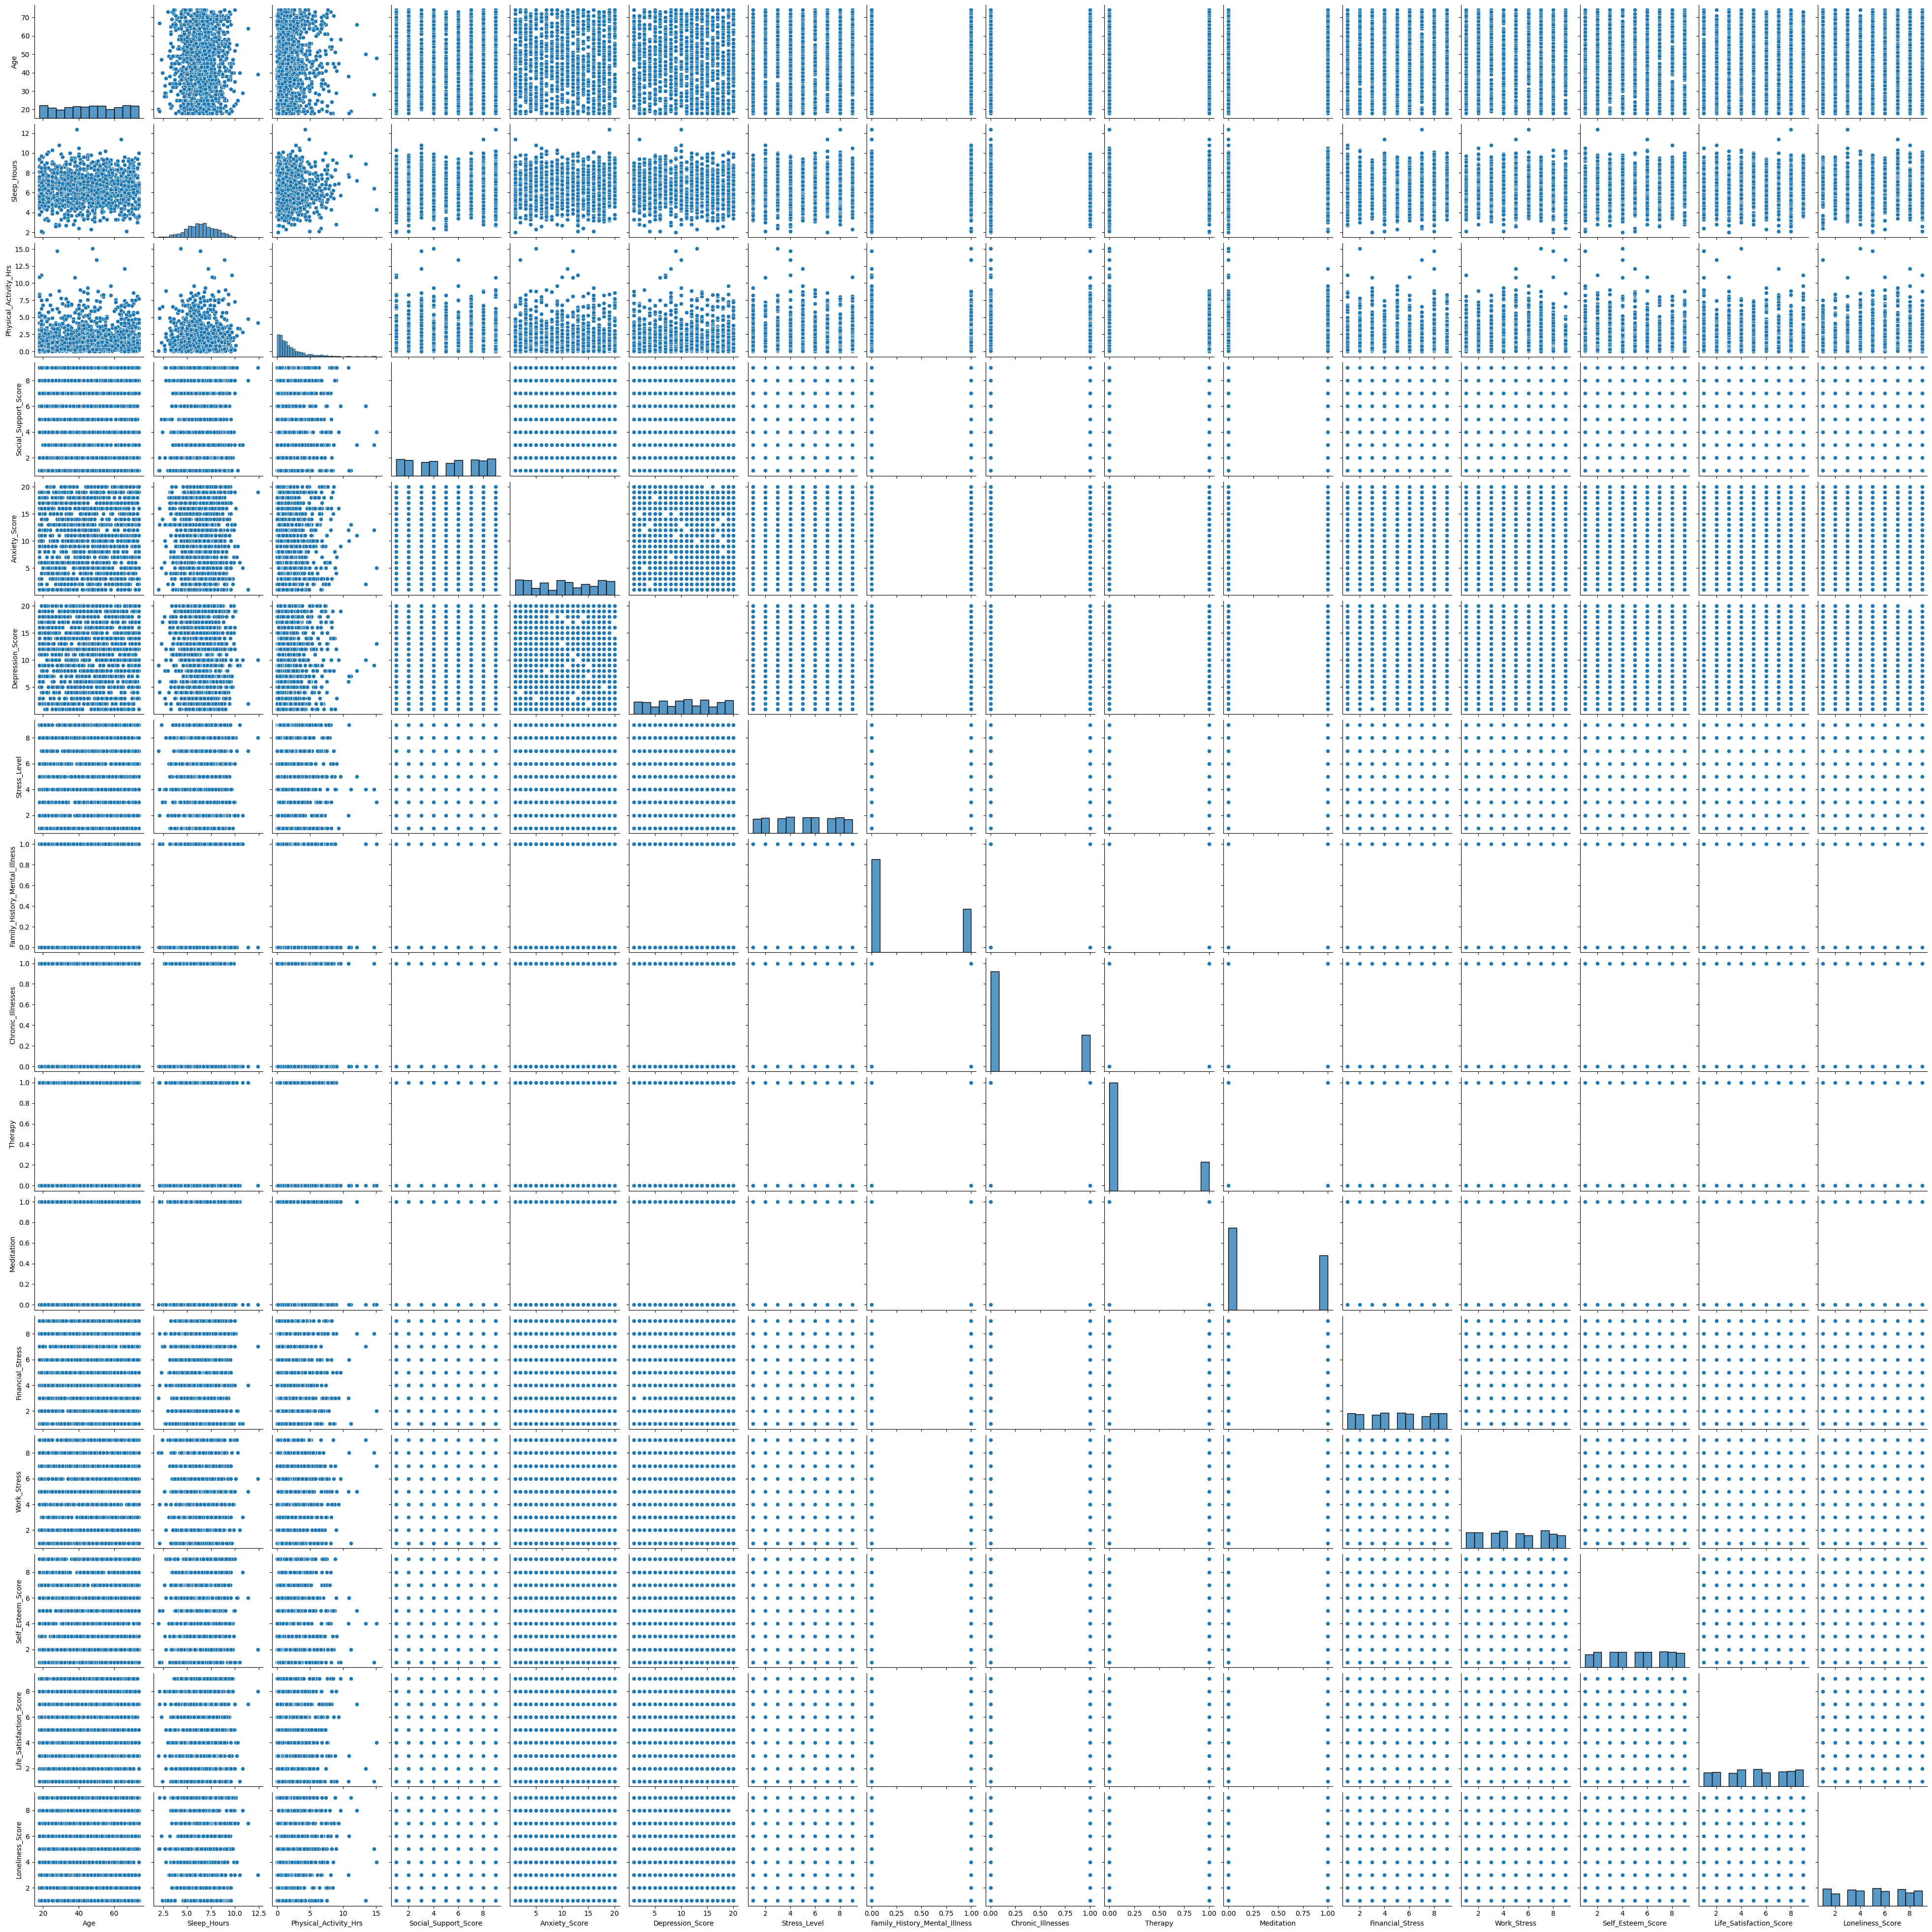

In [ ]:
# Парные представления данных
sns.pairplot(data_num)
plt.show()

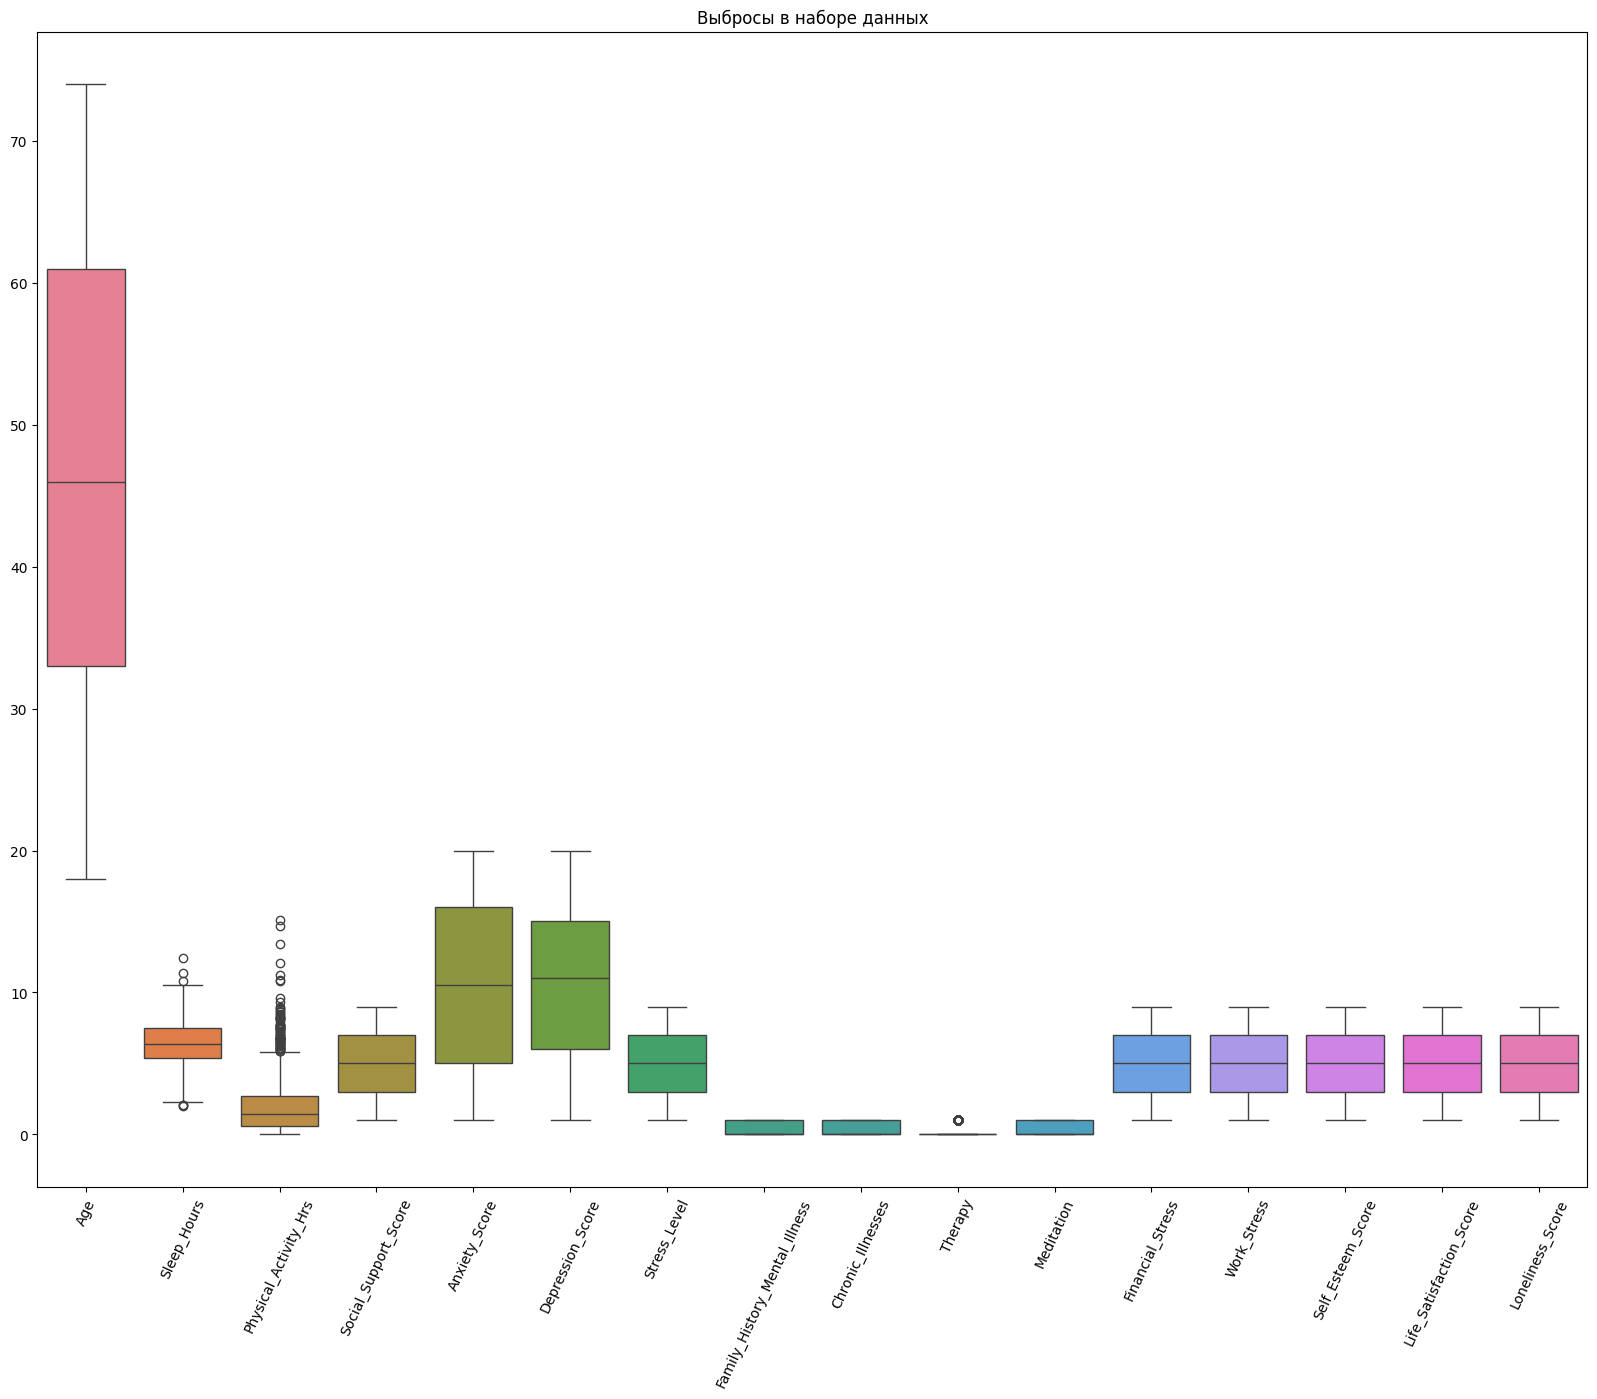

In [ ]:
# Выбросы в наборе данных
plt.figure(figsize=(20,15))
sns.boxplot(data_num)
plt.xticks(rotation = 65)
plt.title('Выбросы в наборе данных')
plt.show()

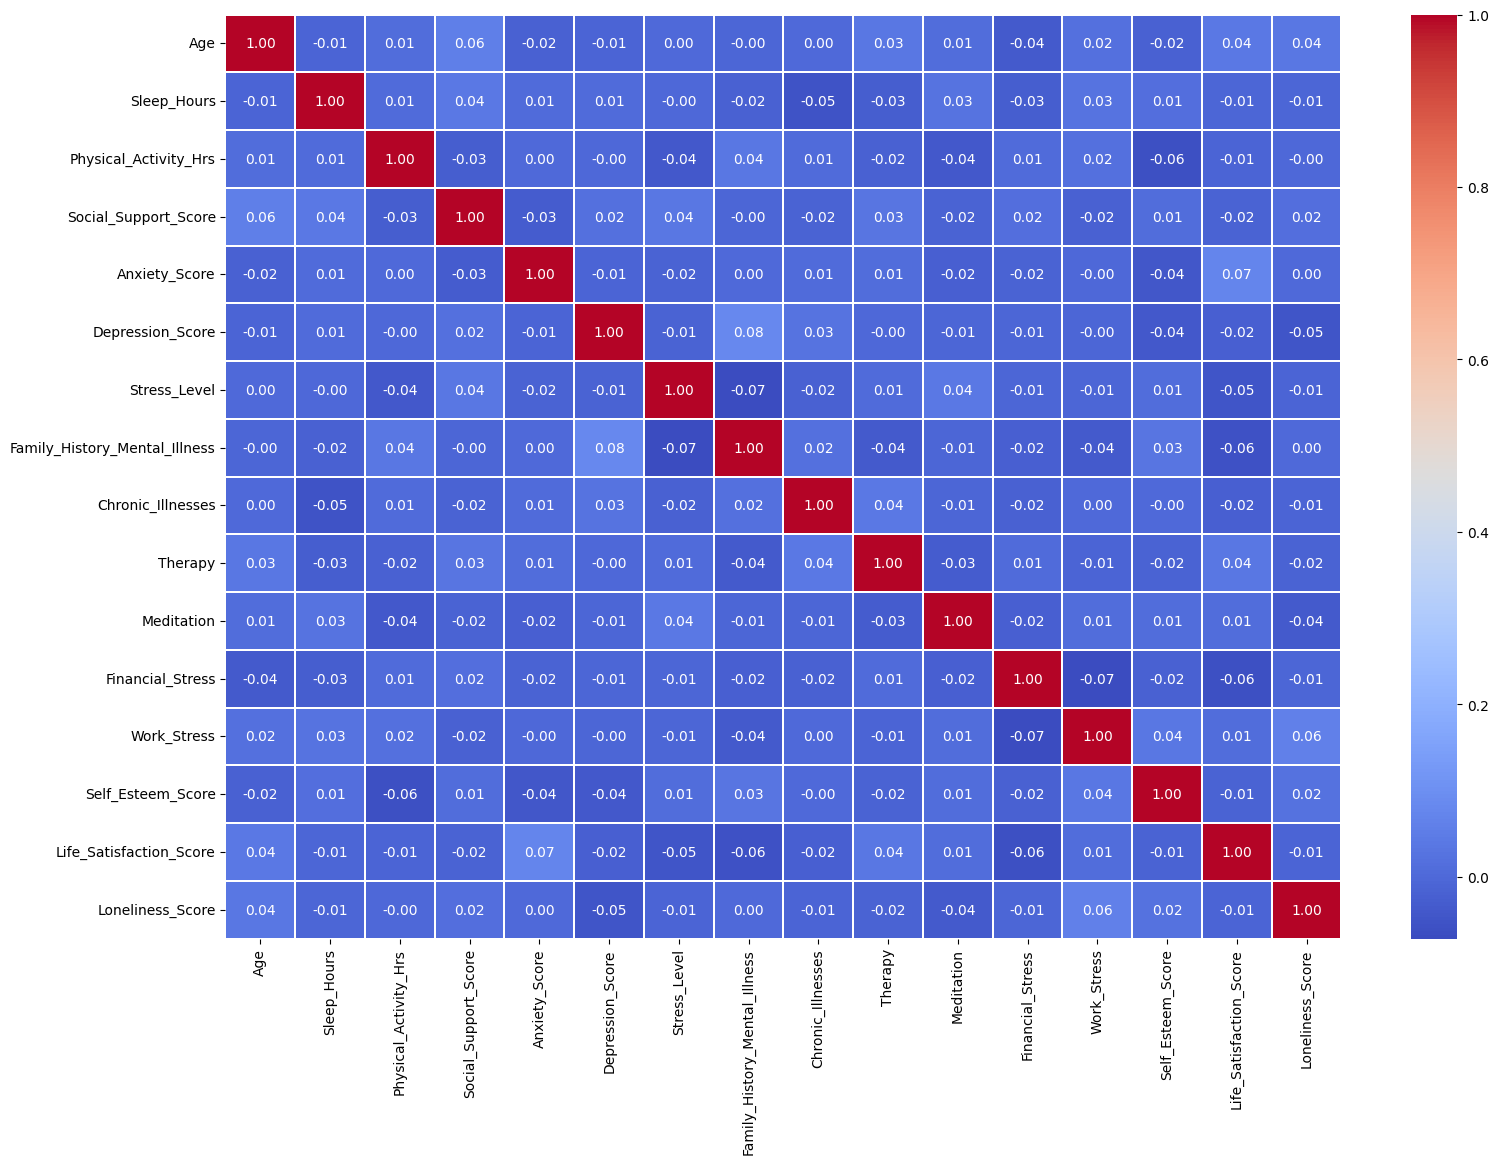

In [ ]:
# Корреляция параметров
plt.figure(figsize=(18,12))
sns.heatmap(data_num.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.01)
plt.show()

In [ ]:
data_model = data.copy()


data_model = dataset.data_encode(data_model)

"""
encoder = LabelEncoder()

for col in data_model.select_dtypes(include=['object']).columns:
    data_model[col] = encoder.fit_transform(data_model[col])
"""
data_model.head()

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Chronic_Illnesses,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
0,56,1,0,3,6.0,0.4,3,4,2,9,...,0,0,0,1,1,4,3,7,5,1
1,69,0,0,1,8.8,2.8,6,18,7,6,...,0,0,1,0,1,1,4,7,4,6
2,46,0,2,0,5.3,1.6,5,5,13,8,...,0,0,0,1,1,8,7,8,1,1
3,32,0,1,3,8.8,0.5,4,6,3,4,...,1,0,0,0,1,7,4,8,4,4
4,60,0,0,1,7.2,0.7,2,7,15,3,...,0,0,1,1,0,8,9,5,7,7


In [ ]:

X, y = dataset.param_sort(data_model, 'Stress_Level')

"""
X = data_model.drop('Stress_Level', axis=1)
y = data_model['Stress_Level']
"""

print('X shape', X.shape)
print('y shape', y.shape)

X shape (1200, 20)
y shape (1200,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

print(f'X_train-{X_train.shape}\nX_test-{X_test.shape}\ny_train-{y_train.shape}\ny_test-{y_test.shape}')

X_train-(840, 20)
X_test-(360, 20)
y_train-(840,)
y_test-(360,)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [ ]:
models = {
          'Logistic Regression': LogisticRegression(),
          # 'Random Forest': RandomForestClassifier(),
          'Support Vector Machine': SVC(),
          'K-Nearest Neighbors': KNeighborsClassifier(),
          'Naive Bayes': GaussianNB(),
          'Decision Tree': DecisionTreeClassifier()
         }

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Logistic Regression Accuracy: 0.1417
              precision    recall  f1-score   support

           1       0.24      0.13      0.17        39
           2       0.08      0.11      0.09        37
           3       0.16      0.28      0.20        32
           4       0.18      0.18      0.18        44
           5       0.07      0.10      0.08        41
           6       0.11      0.08      0.10        49
           7       0.13      0.10      0.11        41
           8       0.13      0.17      0.15        36
           9       0.30      0.17      0.22        41

    accuracy                           0.14       360
   macro avg       0.16      0.15      0.14       360
weighted avg       0.16      0.14      0.14       360

--------------------------------------------------
Support Vector Machine Accuracy: 0.1278
              precision    recall  f1-score   support

           1       0.18      0.13      0.15        39
           2       0.04      0.05      0.05        37
    

In [ ]:
# Дроп признаков
data_model = data_model.drop(columns=['Medication_Use','Substance_Use',
                                      'Sleep_Hours','Physical_Activity_Hrs',
                                      'Financial_Stress' ,'Work_Stress'])

X = data_model.drop('Stress_Level', axis=1)
y = data_model['Stress_Level']

print('X shape', X.shape)
print('y shape', y.shape)

X shape (1200, 14)
y shape (1200,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

print(f'X_train-{X_train.shape}\nX_test-{X_test.shape}\ny_train-{y_train.shape}\ny_test-{y_test.shape}')

X_train-(840, 14)
X_test-(360, 14)
y_train-(840,)
y_test-(360,)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

models = {
          'Logistic Regression': LogisticRegression(),
          # 'Random Forest': RandomForestClassifier(),
          'Support Vector Machine': SVC(),
          'K-Nearest Neighbors': KNeighborsClassifier(),
          'Naive Bayes': GaussianNB(),
          'Decision Tree': DecisionTreeClassifier()
         }

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Logistic Regression Accuracy: 0.1389
              precision    recall  f1-score   support

           1       0.09      0.05      0.06        39
           2       0.07      0.11      0.09        37
           3       0.18      0.28      0.22        32
           4       0.22      0.25      0.23        44
           5       0.06      0.07      0.06        41
           6       0.16      0.12      0.14        49
           7       0.19      0.07      0.11        41
           8       0.15      0.22      0.18        36
           9       0.18      0.10      0.13        41

    accuracy                           0.14       360
   macro avg       0.14      0.14      0.14       360
weighted avg       0.14      0.14      0.13       360

--------------------------------------------------
Support Vector Machine Accuracy: 0.1306
              precision    recall  f1-score   support

           1       0.13      0.10      0.11        39
           2       0.02      0.03      0.02        37
    